## utils

In [32]:
import torch, torch_geometric
import numpy as np
import networkx as nx

import pandas as pd

import sys
from itertools import product

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator

from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42

%config InlineBackend.figure_format = 'retina'

## functions

In [2]:
def random_in_range(rng):
    return (rng[1] - rng[0]) * torch.rand(1).item() + rng[0]

In [3]:
def define_tensor(edge_index, edge_attr, node_vects = None):
    tensor = type('obj', (object,), {})()
    tensor.edge_index = torch.as_tensor(edge_index, device=device)
    if edge_attr is None:
        edge_attr = torch.ones(edge_index.size(1), dtype=torch.float).unsqueeze(1)
    tensor.edge_attr = torch.as_tensor(edge_attr, device=device)
    tensor.node_vects = node_vects
        
    return tensor

def is_hermitian(A: torch.Tensor,
                       rtol=1e-5,
                       atol=1e-8,
                       require_finite=True):
    """
    Check if a (complex or real) PyTorch 2D tensor is Hermitian.

    Works on CPU or GPU. For float dtypes, effectively checks symmetry.

    Returns
    -------
    bool
    """
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        return False
    if require_finite and not torch.isfinite(A).all():
        return False

    # Conjugate transpose
    A_H = A.conj().t()

    # torch.allclose uses elementwise check with given tolerances
    ok = torch.allclose(A, A_H, rtol=rtol, atol=atol)
    return ok

def ge(tensor, linv):
   return float(torch.sqrt(tensor.node_vects.t().matmul(linv.matmul(tensor.node_vects))).cpu().numpy())

def ge_complex(tensor, linv):
   node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)
   return torch.sqrt(node_vects.t().matmul(linv.matmul(node_vects))).cpu().numpy()

#### Laplacians

In [4]:
def laplacian(tensor):
    num_nodes = tensor.edge_index.max() + 1 if tensor.edge_index.min() == 0 else tensor.edge_index.max()
    A = torch.zeros((num_nodes, num_nodes), dtype = torch.float).to(device)
    A[tensor.edge_index[0], tensor.edge_index[1]] = tensor.edge_attr[:,0]

    D = torch.diag(torch.abs(A).sum(dim = 1))

    return D - A

def signed_laplacian(tensor):
    num_nodes = tensor.edge_index.max() + 1 if tensor.edge_index.min() == 0 else tensor.edge_index.max()
    A = torch.zeros((num_nodes, num_nodes), dtype = torch.float).to(device)
    A[tensor.edge_index[0], tensor.edge_index[1]] = tensor.edge_attr[:,0]

    A = A + A.T
    A = A / 2

    D = torch.diag(torch.abs(A).sum(dim = 1))

    return D - A

def magnetic_laplacian(tensor, theta = torch.pi / 2):
	num_nodes = tensor.edge_index.max() + 1 if tensor.edge_index.min() == 0 else tensor.edge_index.max()
	H = torch.zeros(num_nodes, num_nodes, dtype = torch.cfloat).to(device)
	
	phase = torch.exp(1j * torch.as_tensor(theta, dtype = torch.cfloat)).to(device)
	H[tensor.edge_index[0], tensor.edge_index[1]] = tensor.edge_attr[:,0] * phase
	
	H = H + H.conj().T
	H = H / 2
	
	D = torch.diag(torch.abs(H).sum(dim = 1))
	
	return D - H


In [5]:
def study_network(graph, study_bitmap = [0, 0, 1], theta = torch.pi / 2):
    edge_index, edge_attr, node_vects = graph['edge_index'], graph['edge_attr'], graph['node_vects']

    tensor_graph = define_tensor(edge_index, edge_attr, node_vects=node_vects)
    
    results = []
    
    if study_bitmap[0]:
        L = laplacian(tensor_graph)
        inv_L = torch.linalg.pinv(L, hermitian = True)
        ge_L = ge(tensor_graph, inv_L)

        results.append(dict(L=L, inv=inv_L, ge=ge_L, label='L'))
    if study_bitmap[1]:
        SL = signed_laplacian(tensor_graph)
        inv_SL = torch.linalg.pinv(SL, hermitian = True)
        ge_SL = ge(tensor_graph, inv_SL)

        results.append(dict(L=SL, inv=inv_SL, ge=ge_SL, label='SL'))
    if study_bitmap[2]:
        MSL = magnetic_laplacian(tensor_graph, theta = theta)

        inv_MSL = torch.linalg.pinv(MSL, hermitian = is_hermitian(MSL))
        ge_MSL = ge_complex(tensor_graph, inv_MSL)

        results.append(dict(L=MSL, inv=inv_MSL, ge=ge_MSL, label='MSL'))

    return results
        

## toy examples

In [4]:
# nodo = user

# edge_index: c'è stata un'interazione
# edge_attr: num interazioni e tipo (positivo/negativo)
    # provare a usarlo come differenza tra interazioni positive e negative

# node_vects: opinione (prog = -1/cons = +1)

toy_examples = [
    # 1: Simple reciprocal edge
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 2: Simple directed edge A -> B | Should be same as #4
    dict(
        edge_index = torch.tensor([
            (0, 1),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 3: Simple directed edge A <- B | Should be same as #6
    dict(
        edge_index = torch.tensor([
            (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 4: Simple directed positive edge A -> B | Should be same as #2
    dict(
        edge_index = torch.tensor([
            (0, 1),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 5: Simple directed negative edge A -> B
    dict(
        edge_index = torch.tensor([
            (0, 1),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([-1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 6: Simple directed positive edge A <- B | Should be same as #3
    dict(
        edge_index = torch.tensor([
            (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
    # 7: Simple directed negative edge A <- B
    dict(
        edge_index = torch.tensor([
            (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([-1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([1.0, -1.0], dtype=torch.float).to(device),
    ),
]

OLD_polarization_examples = [
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1),  # fully connected positive triangle
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, 1, 1, 1, 1]).unsqueeze(1).float().to(device),  # all positive
        node_vects = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float).to(device),  # neutral opinions
        name = "No polarization - fully positive, neutral opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 0),  # cycle with mixed signs
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, -0.5, 0.5]).unsqueeze(1).float().to(device),  # mixed positive/negative
        node_vects = torch.tensor([-0.3, 0.0, 0.3], dtype=torch.float).to(device),  # gradual shift
        name = "Moderate polarization - mixed edges, gradual opinions"
    ),

    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),  # positive within cluster A
            (2, 3), (3, 2),  # positive within cluster B
            (0, 2), (1, 3),  # negative cross-edges
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, 1, 1, -2, -2]).unsqueeze(1).float().to(device),  # strong negatives
        node_vects = torch.tensor([-1.0, -1.0, 1.0, 1.0], dtype=torch.float).to(device),  # extreme opposites
        name = "High polarization - bipartite with strong negatives"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),  # positive reciprocal
            (0, 2),  # one-way negative from A to B
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, -1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.8, -0.8, 0.8], dtype=torch.float).to(device),  # polarized opinions
        name = "Directional asymmetry - one-way hostility"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),  # positive within cluster A
            (2, 3), (3, 2),  # positive within cluster B
            (0, 2), (1, 3),  # negative cross-edges
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([10, 10, 10, 10, -20, -20]).unsqueeze(1).float().to(device),  # 10x scaled
        node_vects = torch.tensor([-10.0, -10.0, 10.0, 10.0], dtype=torch.float).to(device),  # 10x scaled opinions
        name = "Scale invariance test - 10x scaled bipartite"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([0.0, 0.0], dtype=torch.float).to(device),
        name = "Low polarization - mutual positive, neutral opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([-1, -1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.5, 0.5], dtype=torch.float).to(device),
        name = "High polarization - mutual negative, opposing opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([0.5, -0.5, 0.5]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.2, 0.0, 0.2], dtype=torch.float).to(device),
        name = "Moderate polarization - cycle with mixed edges, slight opinion gradient"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0), (0, 2), (2, 1),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, -1, -1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-1.0, -1.0, 1.0], dtype=torch.float).to(device),
        name = "High polarization - two clusters with intra-positive, inter-negative"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 0), (0, 3), (3, 1), (1, 3),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, 1, -1, -1, -1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.8, -0.4, 0.4, 0.8], dtype=torch.float).to(device),
        name = "Moderate polarization - directed cycle with mixed signs, gradual opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0), (2, 3), (3, 2),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, 1, 1, 1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-1.0, -1.0, 1.0, 1.0], dtype=torch.float).to(device),
        name = "High polarization - two isolated positive pairs, extreme opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 0), (0, 2), (2, 1), (1, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([0.8, -0.8, 0.8, -0.8, 0.8, -0.8]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.6, 0.0, 0.6], dtype=torch.float).to(device),
        name = "Moderate polarization - fully connected with alternating signs, moderate opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 3), (3, 0),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([1, -1, 1, -1]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.9, -0.3, 0.3, 0.9], dtype=torch.float).to(device),
        name = "High polarization - directed cycle with alternating signs, polarized opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([0.5, 0.5, 0.5, 0.5, 0.5, 0.5]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([0.1, -0.1, 0.0], dtype=torch.float).to(device),
        name = "Low polarization - fully connected positive, near-neutral opinions"
    ),
    dict(
        edge_index = torch.tensor([
            (0, 1), (1, 2), (2, 0), (0, 3), (3, 2),
            ], dtype=torch.long).t().contiguous(),
        edge_attr = torch.tensor([-0.7, 0.7, -0.7, 0.7, -0.7]).unsqueeze(1).float().to(device),
        node_vects = torch.tensor([-0.5, 0.5, -0.5, 0.5], dtype=torch.float).to(device),
        name = "High polarization - directed paths with mixed signs, alternating opinions"
    ),
]

In [21]:
for index, example in enumerate(toy_examples):
    if 'node_vects' not in example or example['node_vects'] is None:
        node_vects = torch.tensor(torch.rand(example['edge_index'].max()), dtype=torch.float).to(device)
        example['node_vects'] = node_vects

    sys.stdout.write(f"#{(index+1):02}: {example.get('name', 'Unnamed')}")
    for i in range(example['node_vects'].size(0)):
        sys.stdout.write(f" | Node {chr(i + 65)}: {example['node_vects'][i].item()}")
    print()

    res = study_network(example, study_bitmap=[1, 1, 1])
    
    print("\tLaplacian GE:", res['L']['ge_L'])
    print("\tSigned Laplacian GE:", res['SL']['ge_SL'])
    print("\tMagnetic Laplacian GE:", res['MSL']['ge_MSL'])

#01: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 0.9999999403953552
	Signed Laplacian GE: 0.9999999403953552
	Magnetic Laplacian GE: (0.99999994+0j)
#02: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 1.0
	Signed Laplacian GE: 1.4142135381698608
	Magnetic Laplacian GE: (0.99999994+0j)
#03: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 0.9999999403953552
	Signed Laplacian GE: 1.4142135381698608
	Magnetic Laplacian GE: (0.99999994+0j)
#04: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 1.0
	Signed Laplacian GE: 1.4142135381698608
	Magnetic Laplacian GE: (0.99999994+0j)
#05: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 1.0
	Signed Laplacian GE: 0.0
	Magnetic Laplacian GE: (0.99999994+0j)
#06: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: 0.9999999403953552
	Signed Laplacian GE: 1.4142135381698608
	Magnetic Laplacian GE: (0.99999994+0j)
#07: Unnamed | Node A: 1.0 | Node B: -1.0
	Laplacian GE: nan
	Signed Laplacian GE: 0.0
	Magnetic Laplacian GE: (0.9999

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_23720/220729502.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


## Reddit Networks

In [ ]:
edge = pd.read_csv(f"01_preprocess/final_networks/22_51_edges.tsv", sep = "\t")
nodes = pd.read_csv(f"01_preprocess/final_networks/22_51_nodes.tsv", sep = "\t")

columns_to_drop = ["community", "abortion", "climate", "gender", "guns", "health", "racial_justice", "unauthorized_immigration"]

graph = dict(
    edge_index = torch.tensor(np.array([pd.concat([edge["#src"], edge["trg"]]).values, pd.concat([edge["trg"], edge["#src"]]).values]), dtype = torch.long).to(device),
    edge_attr = torch.tensor(pd.concat([edge[["weight"]], edge[["weight"]]]).values, dtype = torch.float32).to(device),
    node_vects = torch.tensor(nodes.sort_values(by = "node").set_index("node").drop(columns=columns_to_drop, axis = 1).values, dtype = torch.float32).to(device),
    name = "Reddit 2022W51 network"
)

graph['edge_index'].size(), graph['edge_attr'].size(), graph['node_vects'].size()

(torch.Size([2, 37620]), torch.Size([37620, 1]), torch.Size([6299, 1]))

In [ ]:
res = study_network(graph, study_bitmap=[1, 1, 1])
print("\tLaplacian GE:", res['L']['ge_L'])
print("\tSigned Laplacian GE:", res['SL']['ge_SL'])
print("\tMagnetic Laplacian GE:", res['MSL']['ge_MSL'])

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_23298/743137112.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(torch.sqrt(tensor.node_vects.t().matmul(linv.matmul(tensor.node_vects))).cpu().numpy())


In [ ]:
new_edges = edge.copy()
new_edges['weight'] = edge.apply(lambda row: -row['weight'] if row['toxic'] > 0.5 else +row['weight'], axis=1)

graph = dict(
    edge_index = torch.tensor(np.array([pd.concat([edge["#src"]]).values, pd.concat([edge["trg"]]).values]), dtype = torch.long).to(device),
    edge_attr = torch.tensor(new_edges[["weight"]].values, dtype = torch.float32).to(device),
    node_vects = torch.tensor(nodes.sort_values(by = "node").set_index("node").drop(columns=columns_to_drop, axis = 1).values, dtype = torch.float32).to(device),
    name = "Reddit 2022W51 network - directed edges only"
)

res = study_network(graph, study_bitmap=[0, 0, 1], theta = 0.8 * torch.pi) # g = 2/5
print("\tMagnetic Laplacian GE:", res['MSL']['ge_MSL'])

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_62249/2914666109.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


	Magnetic Laplacian GE: [[23.269371+2.2285107e-07j]]


In [ ]:
# Polarization asymmetry between democrats and conservatives

nodes['side'] = nodes['pca'].apply(lambda x: 'left' if x < 0 else ('right' if x > 0 else 'neutral'))

node_side = nodes.set_index('node')['side'].to_dict()

left_to_right_weight = 0.0
right_to_left_weight = 0.0

for _, row in edge.iterrows():
    src = int(row['#src'])
    trg = int(row['trg'])
    weight = row['weight']
    toxic = row['toxic']
    
    src_side = node_side.get(src, 'unknown')
    trg_side = node_side.get(trg, 'unknown')
    
    if src_side == 'left' and trg_side == 'right':
        left_to_right_weight += (weight * toxic)
    elif src_side == 'right' and trg_side == 'left':
        right_to_left_weight += (weight * toxic)

# Results
print("All Edges:")
print(f"\tLeft to Right: {left_to_right_weight}\t|\tRight to Left: {right_to_left_weight}")
print(f"\tNet asymmetry (L->R - R->L weight): {left_to_right_weight - right_to_left_weight}")

# --------------------------------------------------------------------------------------------------------------

# toxic edges only
toxic_threshold = 0.95 # it's funny that when toxicity reaches extreme toxicity, then there are more conservatives
toxic_edges = edge[edge['toxic'] > toxic_threshold].copy()

left_to_right_weight_toxic = 0.0
right_to_left_weight_toxic = 0.0

for _, row in toxic_edges.iterrows():
    src = int(row['#src'])
    trg = int(row['trg'])
    weight = row['weight']
    toxic = row['toxic']
    
    src_side = node_side.get(src, 'unknown')
    trg_side = node_side.get(trg, 'unknown')
    
    if src_side == 'left' and trg_side == 'right':
        left_to_right_weight_toxic += (weight * toxic)
    elif src_side == 'right' and trg_side == 'left':
        right_to_left_weight_toxic += (weight * toxic)

print("Toxic Edges Only:")
print(f"\tLeft to Right: {left_to_right_weight_toxic}\t|\tRight to Left: {right_to_left_weight_toxic}")
print(f"\tNet asymmetry (L->R - R->L weight): {left_to_right_weight_toxic - right_to_left_weight_toxic}")

All Edges:
	Left to Right: 1788.8546423321532	|	Right to Left: 1496.4220454196038
	Net asymmetry (L->R - R->L weight): 292.43259691254934
Toxic Edges Only:
	Left to Right: 136.04645770788193	|	Right to Left: 139.66185784339905
	Net asymmetry (L->R - R->L weight): -3.6154001355171204


## magnetic laplacian (unsigned)

### functions

In [46]:
theta = 1 / 2 * torch.pi

chain_lengths = list(sorted(set((np.geomspace(1, 2048, dtype=int)))))
chain_lengths_consecutive = range(1, 512, 20)
communities_sizes = list(sorted(set((np.geomspace(1, 32, dtype=int)))))

edges = ["pos", "neg"]

toxicity_threshold = 0.65
toxicity_range = (0.0, 1.0)

moderates_range = (-0.35, 0.35)

runs = 100

tree = lambda: defaultdict(tree)

In [59]:
def get_weight_from_toxicity(t):
    return max(1 - t, 0.0001)

# if the opinion is extreme, there is a higher chance of toxicity
# in other cases, the toxicity can happen but it's less likely
def generate_toxicity(opinion):
    if opinion < -0.8 or opinion > 0.8:
        return random_in_range((toxicity_threshold, 1.0))
    return random_in_range(toxicity_range)

def build_linear_chained_graph(l, with_toxicity = False):
    def iteratively_build_chain(edge_index, edge_attr, node_vects, start = 0):
        for i in range(start, total_nodes):
            if i == 0:
                weight = get_weight_from_toxicity(generate_toxicity(-1)) if with_toxicity else 1
                # First node (A) with opinion -1
                edge_index.append((i, i + 1))
                edge_attr.append(weight)
                node_vects.append(-1)
                continue
            elif i == total_nodes - 1:
                # Last node (Z) with opinion +1
                node_vects.append(1)
                continue

            random_opinion = random_in_range(moderates_range)
            weight = get_weight_from_toxicity(generate_toxicity(random_opinion)) if with_toxicity else 1

            # Intermediate nodes with neutral opinion
            edge_index.append((i, i + 1))
            edge_attr.append(weight)
            node_vects.append(random_opinion)

        return edge_index, edge_attr, node_vects

    total_nodes = l + 2

    edge_index = []
    edge_attr = []
    node_vects = []

    edge_index, edge_attr, node_vects = iteratively_build_chain(edge_index, edge_attr, node_vects)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr).unsqueeze(1).float().to(device)
    node_vects = torch.tensor(node_vects, dtype=torch.float).to(device)

    return dict(
        edge_index = edge_index,
        edge_attr = edge_attr,
        node_vects = node_vects,
    )

def build_centric_convergent_graph(l, with_toxicity = False):
    edge_index = []
    edge_attr = []
    node_vects = []

    total_nodes = l + 2
    invert = False
    
    for i in range(total_nodes):
        weight = 1
        if i == total_nodes // 2 - 1:
            node_vects.append(1)
            invert = True
            continue
        # if i == total_nodes // 2:
        #     node_vects.append(-1)
        if i == 0:
            node_vects.append(-1)
        elif i == total_nodes - 1:
            node_vects.append(-1)
        else:
            random_opinion = 0# random_in_range(moderates_range)
            weight = get_weight_from_toxicity(generate_toxicity(random_opinion)) if with_toxicity else 1
            node_vects.append(random_opinion)
        edge_index.append((i, i + 1) if not invert else (i, i - 1))
        edge_attr.append(weight)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr).unsqueeze(1).float().to(device)
    node_vects = torch.tensor(node_vects, dtype=torch.float).to(device)


    return dict(
        edge_index = edge_index,
        edge_attr = edge_attr,
        node_vects = node_vects,
    )

def build_extremes_convergent_graph(l, with_toxicity = False):
    edge_index = []
    edge_attr = []
    node_vects = []

    total_nodes = l + 2
    invert = False
    
    for i in range(total_nodes):
        weight = 1
        if i == total_nodes // 2:
            node_vects.append(1)
            invert = True
            continue
        if i == 0:
            node_vects.append(-0.5)
        elif i == total_nodes - 1:
            node_vects.append(-0.5)
        else:
            random_opinion = random_in_range(moderates_range)
            weight = get_weight_from_toxicity(generate_toxicity(random_opinion)) if with_toxicity else 1
            node_vects.append(random_opinion)
        edge_index.append((i - 1, i) if invert else (i + 1, i))
        edge_attr.append(weight * 1)
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr).unsqueeze(1).float().to(device)
    node_vects = torch.tensor(node_vects, dtype=torch.float).to(device)


    return dict(
        edge_index = edge_index,
        edge_attr = edge_attr,
        node_vects = node_vects,
    )

def build_community_graph(community_size, intercommunity_size, in_out = False, with_toxicity = False):
    total_nodes = community_size * 2 + intercommunity_size
    second_community = community_size + intercommunity_size
    
    edge_index = []
    edge_attr = []
    node_vects = []
    
    for i in range(0, community_size):
        node_vects.append(-1)
        for j in range(0, community_size):
            if i != j:
                edge_index.append((i, j))
                edge_attr.append(1)
                
    edge_index.append((i, i + 1) if in_out else (i + 1, i))
    weight = get_weight_from_toxicity(generate_toxicity(-1)) if with_toxicity else 1
    edge_attr.append(weight * 1)

    for i in range(community_size, second_community):
        random_opinion = random_in_range(moderates_range)
        weight = get_weight_from_toxicity(generate_toxicity(random_opinion)) if with_toxicity else 1
        if i == second_community - 1:
            edge_index.append((i + 1, i) if in_out else (i, i + 1))
            edge_attr.append(weight * 1)
        else:
            edge_index.append((i, i + 1))
            edge_attr.append(weight * 1)
        node_vects.append(random_opinion)

    for i in range(second_community, total_nodes):
        node_vects.append(1)
        for j in range(second_community, total_nodes):
            if i != j:
                weight = get_weight_from_toxicity(generate_toxicity(-1)) if with_toxicity else 1

                edge_index.append((i, j))
                edge_attr.append(weight * 1)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr).unsqueeze(1).float().to(device)
    node_vects = torch.tensor(node_vects, dtype=torch.float).to(device)

    return dict(
        edge_index = edge_index,
        edge_attr = edge_attr,
        node_vects = node_vects,
    )


In [ ]:
def show_plot(results, title, x_label, theta = theta):
    keys = results.keys()

    fig, axs = plt.subplots(len(keys), figsize=(10, 5 * len(keys)), sharex=True, sharey=True)
    # fig.suptitle(title)

    axs = axs if len(keys) > 1 else [axs]
    
    for ax, key in zip(axs, keys):
        # ax.set_title(key)
        result = results[key]

        # plt.scatter(x, y, color = "#C58011")
        # plt.plot(x, line, color = "#9e0000")

        ax.plot(result.keys(), result.values(), color="#9E0000", label=f"GE vs {key}")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=0.2)

    fig.tight_layout(pad=2.0)

    plt.xlabel(x_label)
    plt.ylabel(f"GE | (theta = {round(theta, 2)}, g = {round(theta / (2 * torch.pi), 2)}). Moderates between [{moderates_range[0]}, {moderates_range[1]}]")
    plt.legend()
    # plt.savefig(f"../output/plots/{title}.svg", transparent=True, dpi=600)
    plt.show()

### tests

In [49]:
torch.initial_seed()

9080058379499499999

/tmp/ipykernel_43330/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


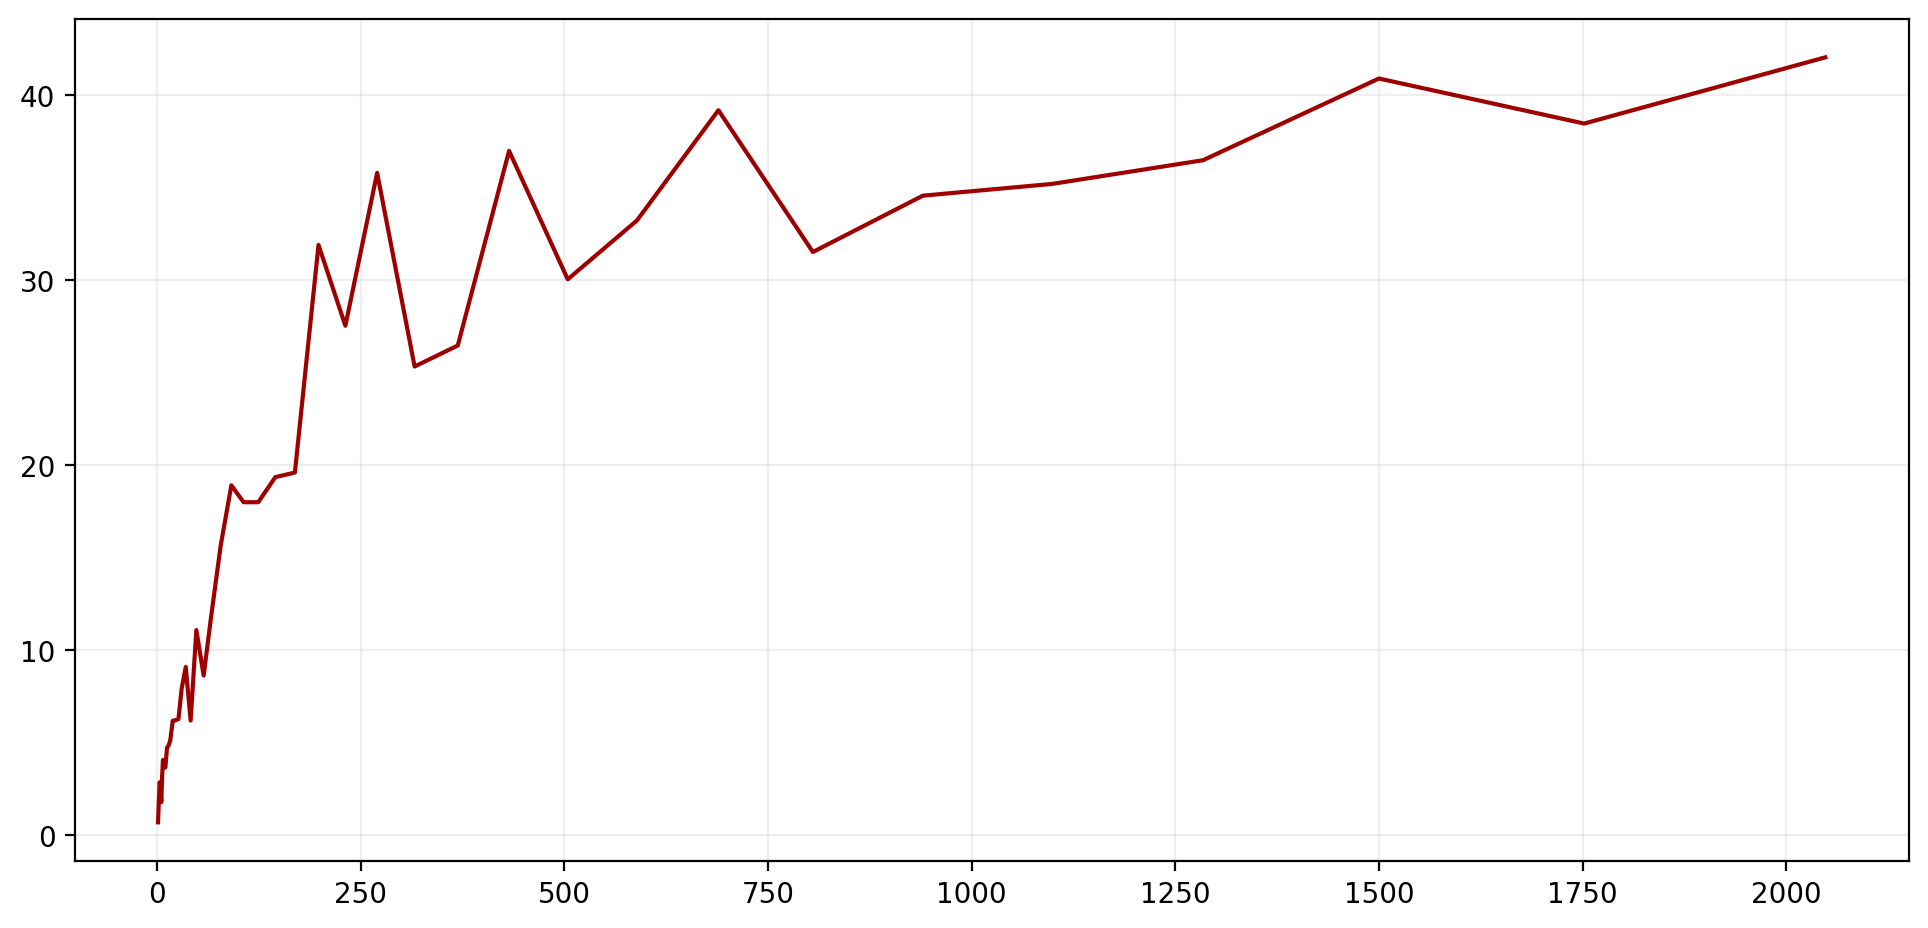

In [ ]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_linear_chained_graph(l)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
    
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "plot-chained-extremes-divergent-graph", x_label = "Chain length", theta=theta)

/tmp/ipykernel_43330/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


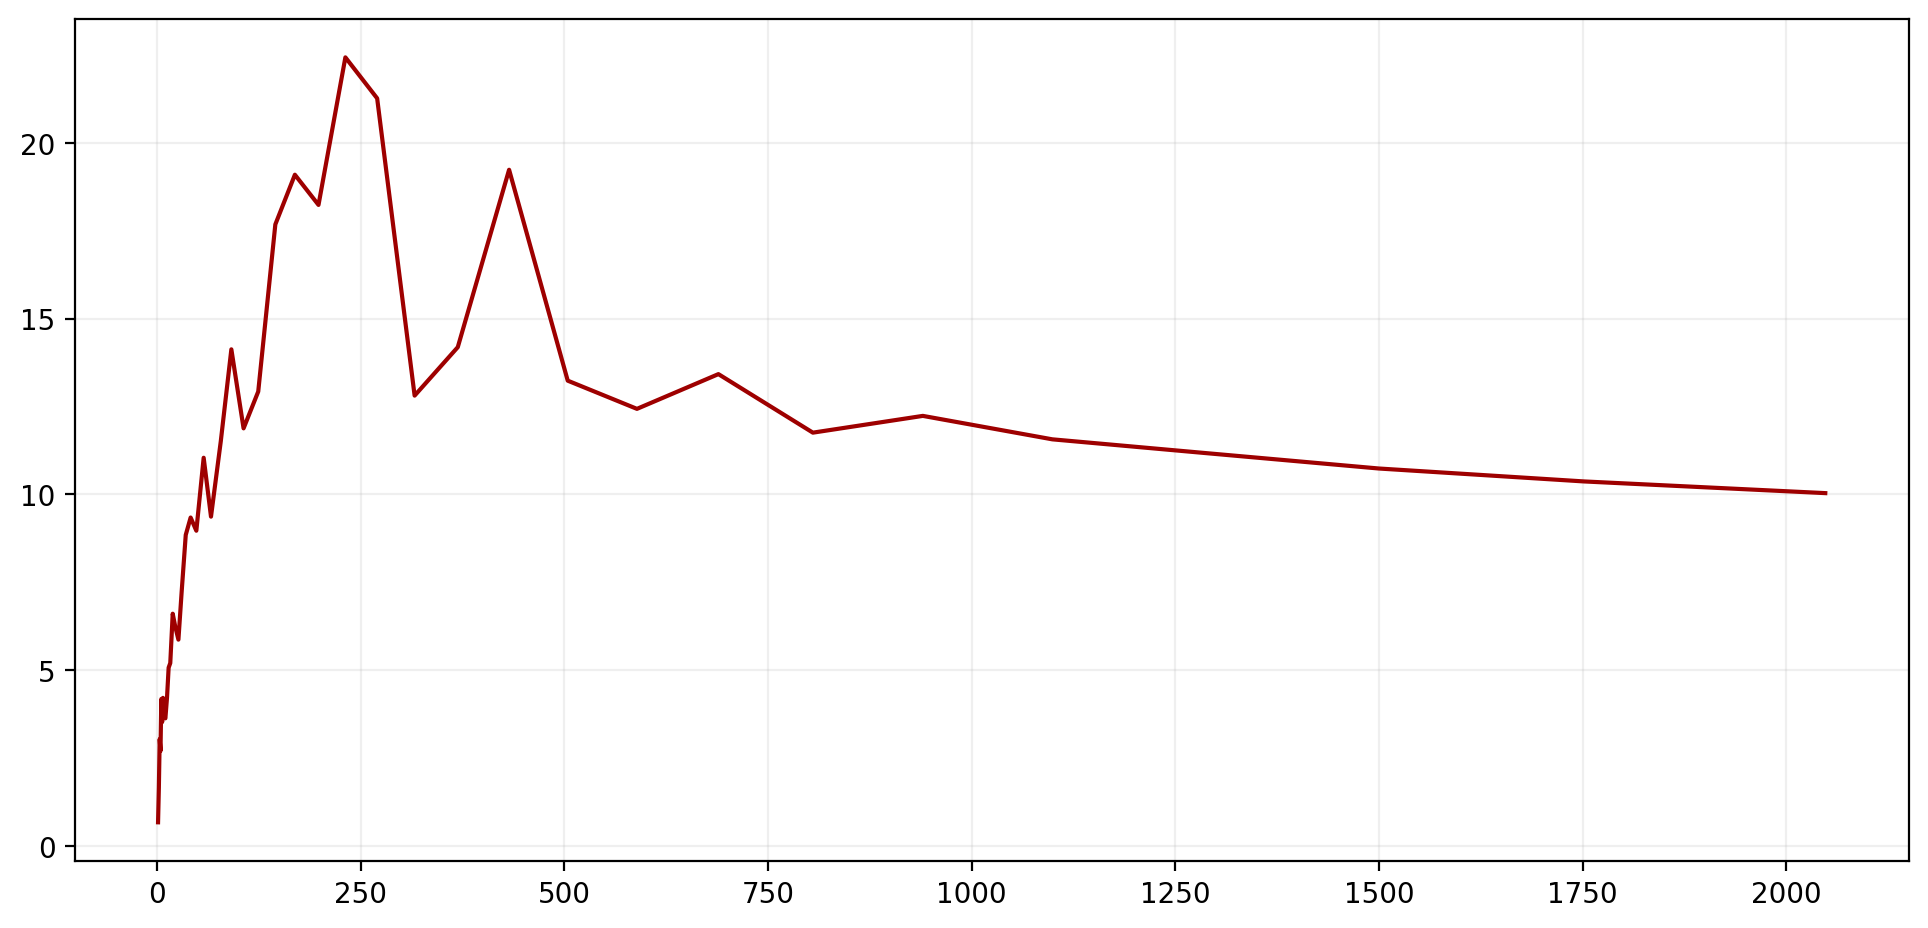

In [60]:
runs = 5
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_centric_convergent_graph(l)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "plot-chained-extremes-convergent-graph", x_label = "Chain length", theta=theta)

/nix/store/rpc8gs6xigbqlj6dc6z5v3h992kb9sr1-python3-3.13.12-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nix/store/rpc8gs6xigbqlj6dc6z5v3h992kb9sr1-python3-3.13.12-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


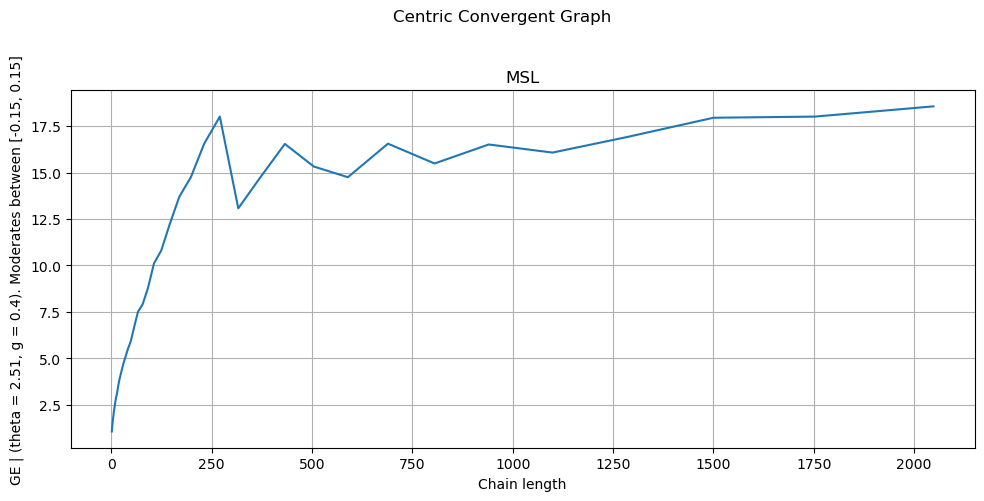

In [ ]:
show_plot(results, title = "Centric Convergent Graph", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_41902/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


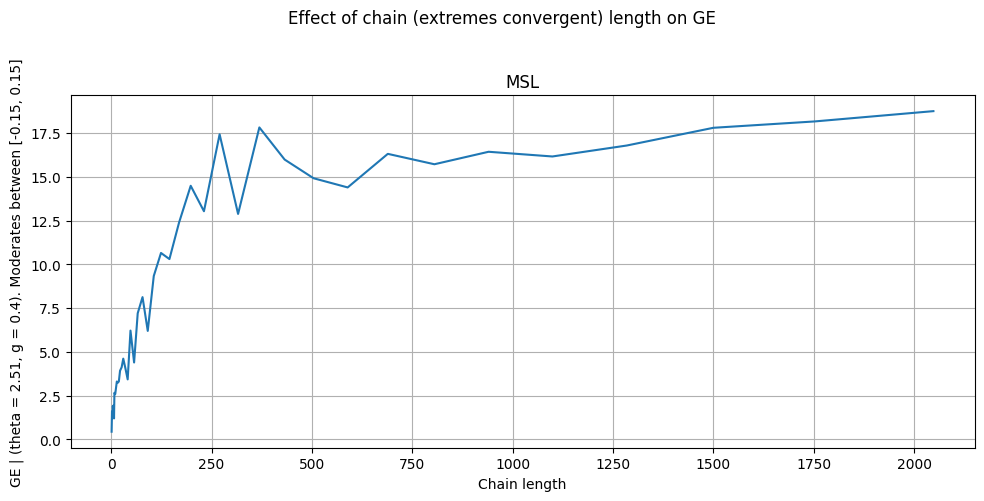

In [84]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_extremes_convergent_graph(l)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of chain (extremes convergent) length on GE", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_41902/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


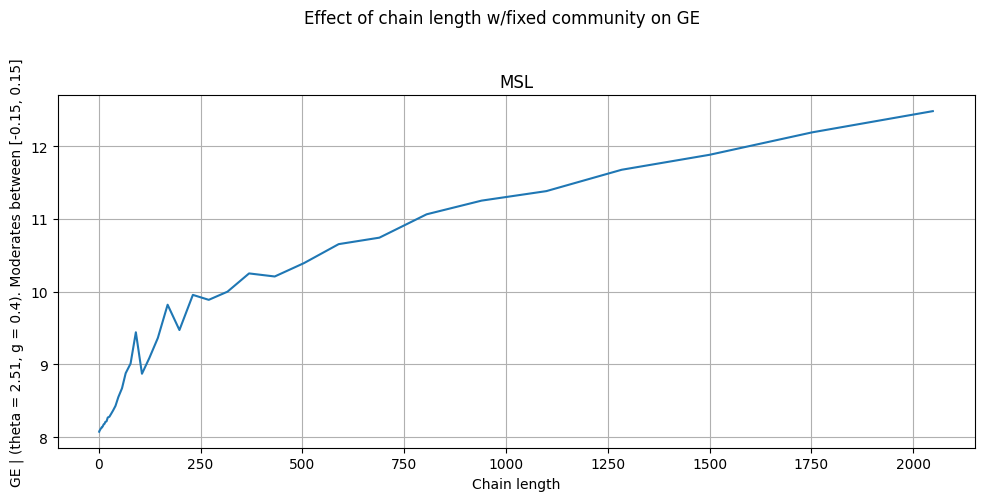

In [85]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_community_graph(16, l)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of chain length w/fixed community on GE", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_41902/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


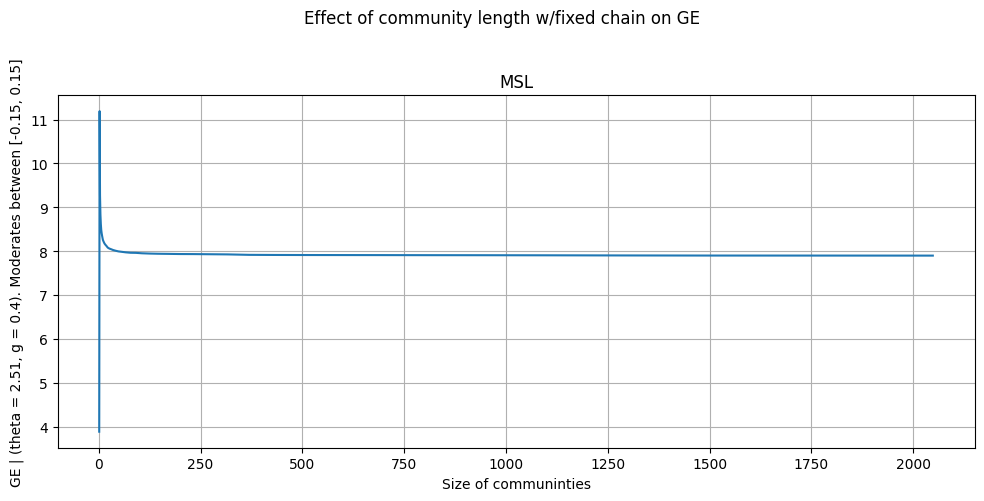

In [86]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_community_graph(l, 9)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of community length w/fixed chain on GE", x_label = "Size of communinties", theta=theta)

### g.e. with random real networks

In [93]:
network_sizes = list(sorted(set((np.geomspace(50, 100, dtype=int)))))
network_sizes = [n for n in network_sizes if n % 4 == 0]

p_in = 0.3
p_out = 0.05

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_41902/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


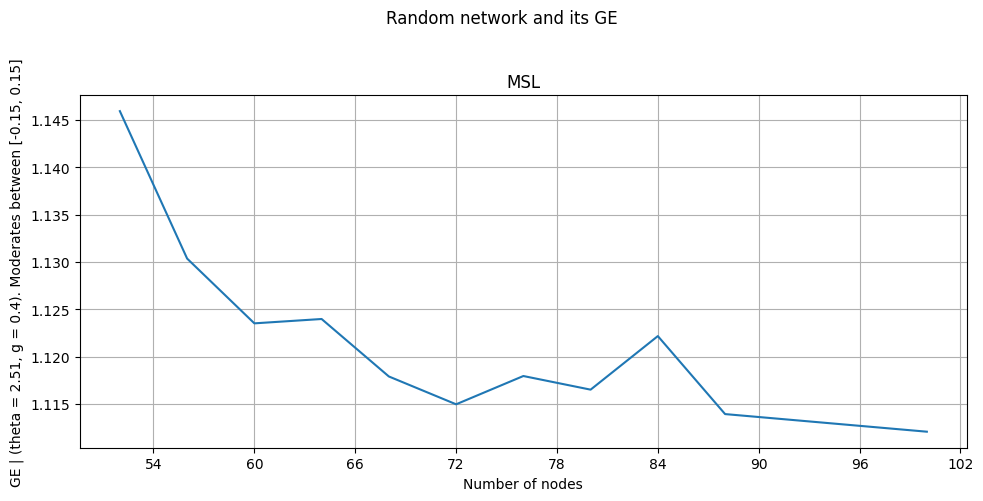

In [ ]:
results = tree()

runs = 1000
for n in network_sizes:
    print(f"{n}/{network_sizes[-1]}", end="\r")
    for i in range(runs):
        graph = nx.gnp_random_graph(n=n, p=p_in, seed=SEED, directed=True)

        for i in range(n):
            graph.nodes[i]['opinion'] = round(random_in_range((-1, 1)), 2)

        tensor_graph = dict(
            edge_index = torch.tensor(np.array(graph.edges).T, dtype = torch.long).to(device),
            edge_attr = torch.tensor([1] * graph.number_of_edges(), dtype = torch.float).unsqueeze(1).to(device),
            node_vects = torch.tensor([graph.nodes[i]['opinion'] for i in range(n)], dtype = torch.float).to(device),
            name = f"BA graph with {n} nodes and {graph.number_of_edges()} edges"
        )

        for result in study_network(tensor_graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(n) is None:
                results[result['label']][n] = 0.0
            results[result['label']][n] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Random network and its GE", x_label = "Number of nodes")

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_41902/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


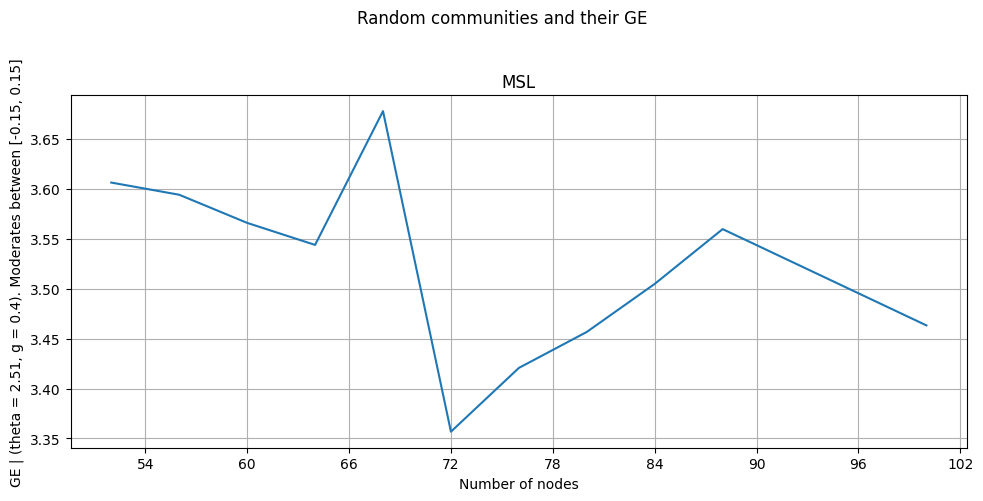

In [ ]:
results = tree()

for n in network_sizes:
    for i in range(runs):
        graph = nx.planted_partition_graph(4, n // 4, p_in, p_out, seed=SEED, directed=True)

        print(f"{n}/{network_sizes[-1]}", end="\r")

        # assigning opinions based on the community
        for i in range(n):
            if graph.nodes[i]['block'] in [0, 2]:
                graph.nodes[i]['opinion'] = random_in_range((-1, -0.9)) # Community 0, 2
            else:
                graph.nodes[i]['opinion'] = random_in_range((0.9, 1))  # Community 1, 3
        
        for i in range(graph.number_of_edges()):
            graph.edges[list(graph.edges)[i]]['weight'] = 1  # All positive edges

        tensor_graph = dict(
            edge_index = torch.tensor(np.array(graph.edges).T, dtype = torch.long).to(device),
            edge_attr = torch.tensor([graph.edges[list(graph.edges)[i]]['weight'] for i in range(graph.number_of_edges())], dtype = torch.float).unsqueeze(1).to(device),
            node_vects = torch.tensor([graph.nodes[i]['opinion'] for i in range(n)], dtype = torch.float).to(device),
            name = f"BA graph with {n} nodes and {graph.number_of_edges()} edges"
        )
        
        for result in study_network(tensor_graph, study_bitmap=[0, 0, 1]):
            if results[result['label']].get(n) is None:
                results[result['label']][n] = 0.0
            results[result['label']][n] += result['ge']
    
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Random communities and their GE", x_label = "Number of nodes", theta = theta)

## unsigned magnetic laplacian w/toxicity `1-t`

### tests

In [54]:
torch.initial_seed()

9080058379499499999

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


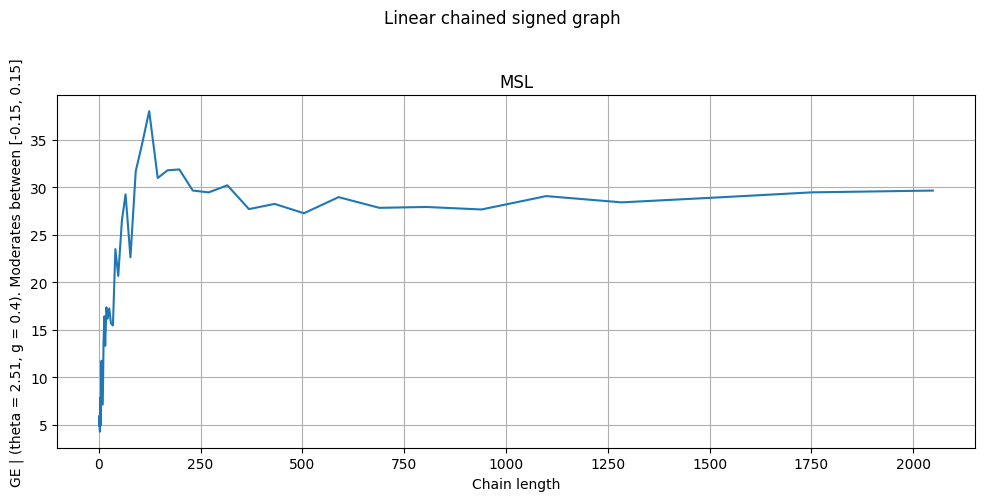

In [55]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_linear_chained_graph(l, with_toxicity=True)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
    
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Linear chained signed graph", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


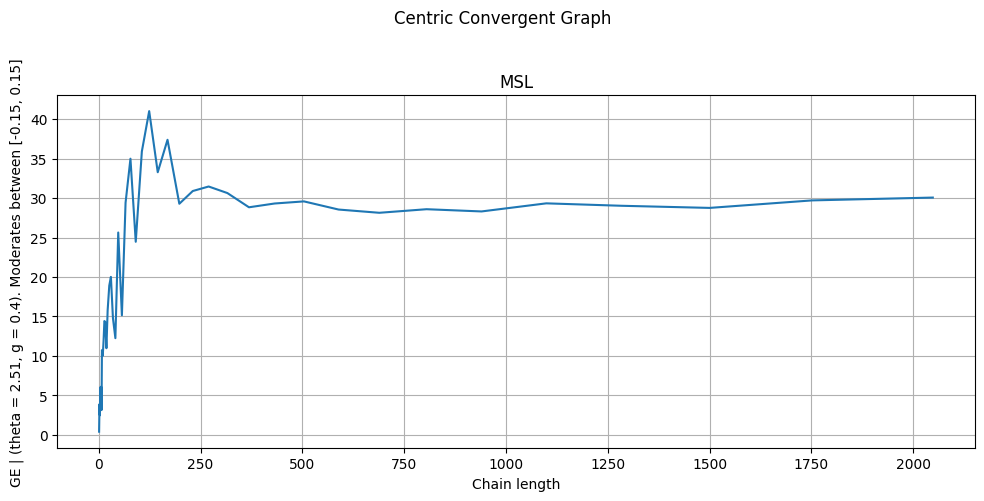

In [56]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_centric_convergent_graph(l, with_toxicity=True)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Centric Convergent Graph", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


/Users/micheledecillis/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


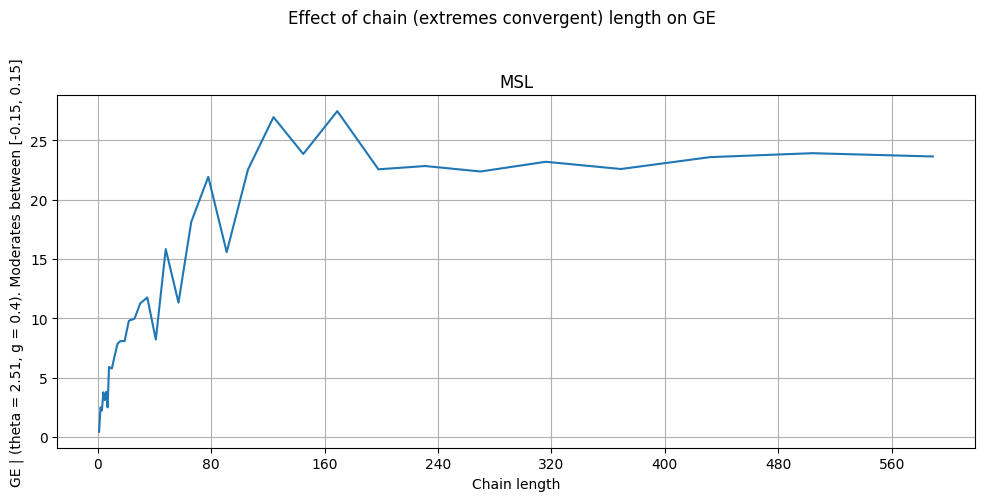

In [102]:
results = tree()

for l in chain_lengths[:35]:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_extremes_convergent_graph(l, with_toxicity=True)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of chain (extremes convergent) length on GE", x_label = "Chain length", theta=theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


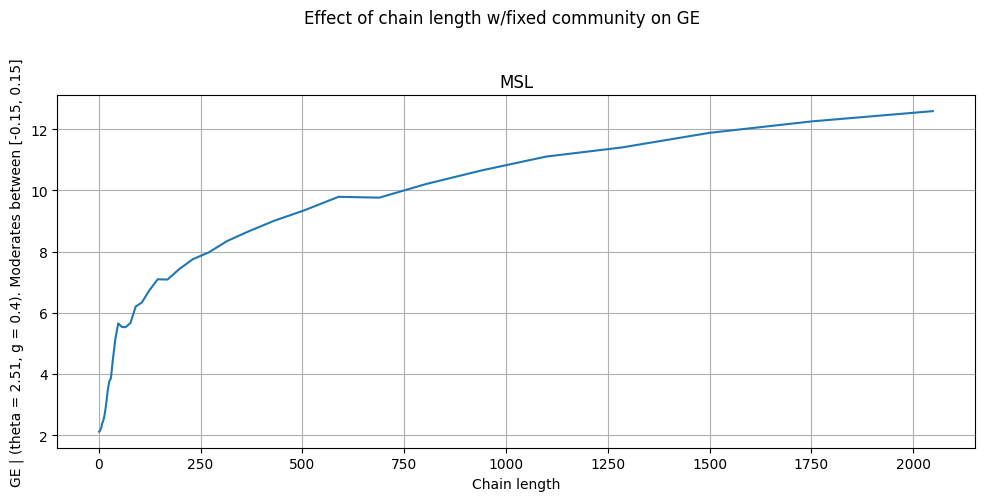

In [59]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_community_graph(16, l, with_toxicity=True)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of chain length w/fixed community on GE", x_label = "Chain length", theta=theta)

In [ ]:
results = tree()

for l in chain_lengths:
    print(f"{l}/{chain_lengths[-1]}", end="\r")
    for i in range(runs):
        graph = build_community_graph(l, 9, with_toxicity=True)

        for result in study_network(graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(l) is None:
                results[result['label']][l] = 0.0
            results[result['label']][l] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Effect of community length w/fixed chain on GE", x_label = "Size of communinties", theta=theta)

/Users/micheledecillis/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


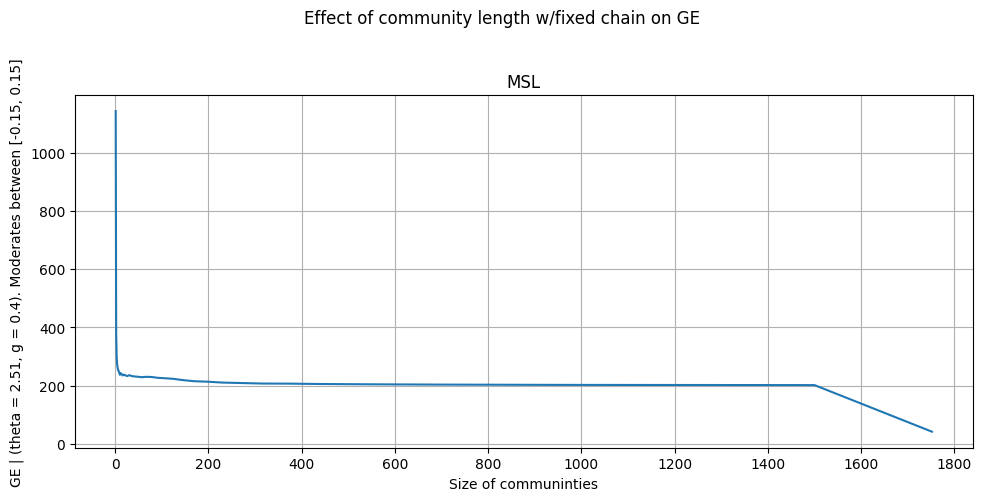

In [62]:
show_plot(results, title = "Effect of community length w/fixed chain on GE", x_label = "Size of communinties", theta=theta)

### g.e. with random real networks

In [234]:
network_sizes = list(sorted(set((np.geomspace(50, 100, dtype=int)))))
network_sizes = [n for n in network_sizes if n % 4 == 0]

p_in = 0.3
p_out = 0.05

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


/Users/micheledecillis/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


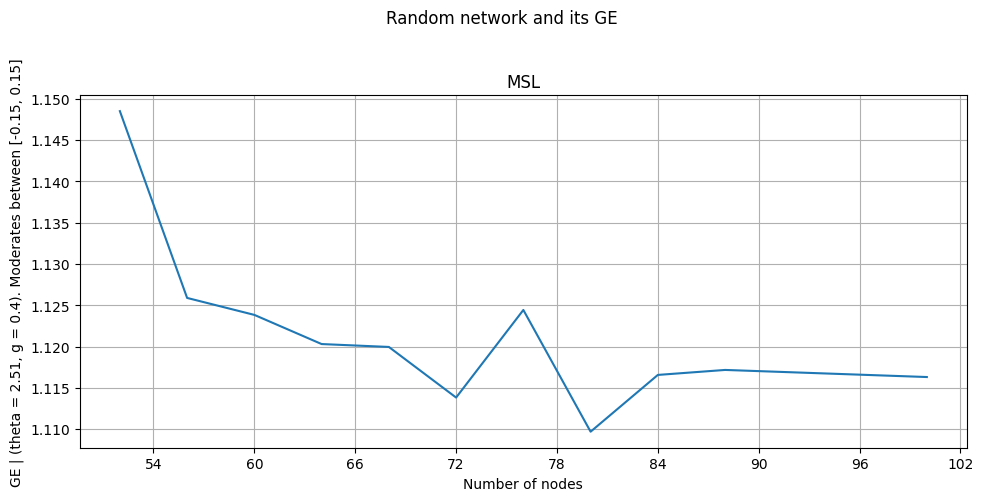

In [ ]:
results = tree()

for n in network_sizes:
    print(f"{n}/{network_sizes[-1]}", end="\r")
    for i in range(runs):
        graph = nx.gnp_random_graph(n=n, p=p_in, seed=SEED, directed=True)

        for i in range(n):
            graph.nodes[i]['opinion'] = round(random_in_range((-1, 1)), 2)
        
        for i in range(graph.number_of_edges()):
            opinion_a = graph.nodes[list(graph.edges)[i][0]]['opinion']
            opinion_b = graph.nodes[list(graph.edges)[i][1]]['opinion']
            if (opinion_a < 0 and opinion_b > 0) or (opinion_a > 0 and opinion_b < 0):
                graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((toxicity_threshold, 1.0)))
            else:
                graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((0.0, toxicity_threshold)))

        tensor_graph = dict(
            edge_index = torch.tensor(np.array(graph.edges).T, dtype = torch.long).to(device),
            edge_attr = torch.tensor([1] * graph.number_of_edges(), dtype = torch.float).unsqueeze(1).to(device),
            node_vects = torch.tensor([graph.nodes[i]['opinion'] for i in range(n)], dtype = torch.float).to(device),
            name = f"BA graph with {n} nodes and {graph.number_of_edges()} edges"
        )

        for result in study_network(tensor_graph, study_bitmap=[0, 0, 1], theta = theta):
            if results[result['label']].get(n) is None:
                results[result['label']][n] = 0.0
            results[result['label']][n] += result['ge']
        
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Random network and its GE", x_label = "Number of nodes")

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_51624/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


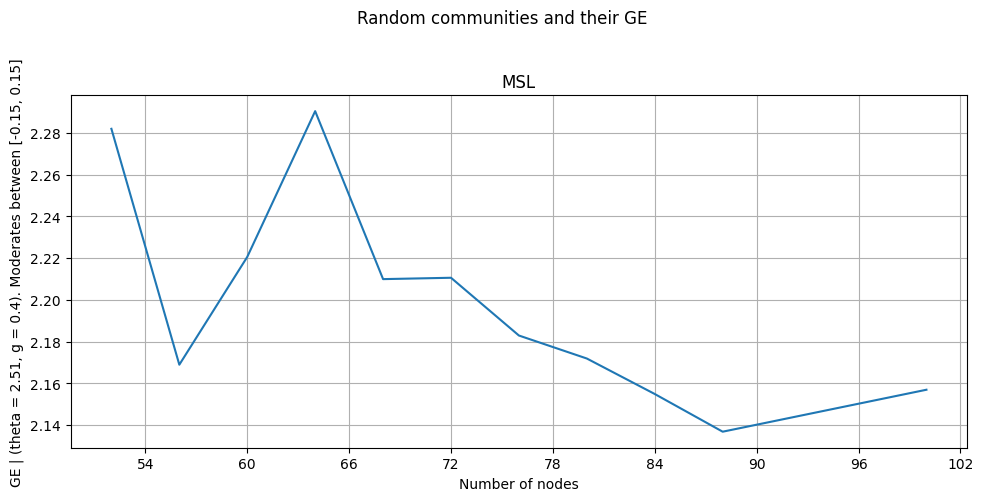

In [ ]:
results = tree()

for n in network_sizes:
    for i in range(runs):
        graph = nx.planted_partition_graph(2, n // 2, p_in, p_out, seed=SEED, directed=True)

        print(f"{n}/{network_sizes[-1]}", end="\r")

        # assigning opinions based on the community
        for i in range(n):
            if graph.nodes[i]['block'] in [0, 2]:
                graph.nodes[i]['opinion'] = random_in_range((-1, -0.0001)) # Community 0, 2
            else:
                graph.nodes[i]['opinion'] = random_in_range((0.0001, 1))  # Community 1, 3
        
        for i in range(graph.number_of_edges()):
            opinion_a = graph.nodes[list(graph.edges)[i][0]]['opinion']
            opinion_b = graph.nodes[list(graph.edges)[i][1]]['opinion']
            if (opinion_a < 0 and opinion_b > 0) or (opinion_a > 0 and opinion_b < 0):
                graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((toxicity_threshold, 1.0)))
            else:
                graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((0.0, toxicity_threshold)))

        tensor_graph = dict(
            edge_index = torch.tensor(np.array(graph.edges).T, dtype = torch.long).to(device),
            edge_attr = torch.tensor([graph.edges[list(graph.edges)[i]]['weight'] for i in range(graph.number_of_edges())], dtype = torch.float).unsqueeze(1).to(device),
            node_vects = torch.tensor([graph.nodes[i]['opinion'] for i in range(n)], dtype = torch.float).to(device),
            name = f"BA graph with {n} nodes and {graph.number_of_edges()} edges"
        )
        
        for result in study_network(tensor_graph, study_bitmap=[0, 0, 1]):
            if results[result['label']].get(n) is None:
                results[result['label']][n] = 0.0
            results[result['label']][n] += result['ge']
    
for label in results.keys():
    for k in results[label].keys():
        results[label][k] /= runs
show_plot(results, title = "Random communities and their GE", x_label = "Number of nodes", theta = theta)

/var/folders/38/f7xqds1j4yx06zmz7ht8r3c40000gn/T/ipykernel_63630/127590184.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_vects = torch.tensor(tensor.node_vects, dtype=torch.cfloat).to(device)


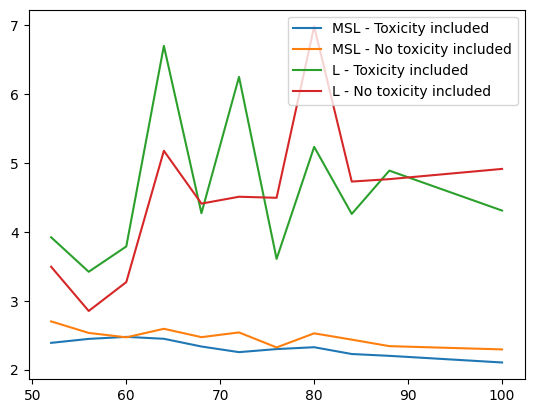

In [235]:
temp_results = defaultdict(lambda: defaultdict(list))
distribution_runs = 50

prev_t = 'MSL'
torch.manual_seed(42)
for i, n, t, toxicity in product(range(distribution_runs), network_sizes, ['MSL', 'L'], [True, False]):
    # Reset seed for each new type to ensure comparable graphs
    if t != prev_t:
        torch.manual_seed(42)
        prev_t = t
    d = (t == 'MSL')

    toxicity_str = "Toxicity included" if toxicity else "No toxicity included"

    print(f"{n}/{network_sizes[-1]} | Run: {i}/{distribution_runs} | {t} | {toxicity_str} | ", end="\r")

    graph = nx.planted_partition_graph(2, n // 2, 0.15, 0.02, seed=SEED, directed=d)
    
    for i in range(n):
        if graph.nodes[i]['block'] in [0]:
            graph.nodes[i]['opinion'] = random_in_range((-1, -0.0001)) # Community 0, 2
        else:
            graph.nodes[i]['opinion'] = random_in_range((0.0001, 1))  # Community 1, 3
    
    for i in range(graph.number_of_edges()):
        opinion_a = graph.nodes[list(graph.edges)[i][0]]['opinion']
        opinion_b = graph.nodes[list(graph.edges)[i][1]]['opinion']
        if (opinion_a < 0 and opinion_b > 0) or (opinion_a > 0 and opinion_b < 0):
            graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((toxicity_threshold, 1.0)))
        else:
            graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((0.0, toxicity_threshold)))
    
    tensor_graph = dict(
        edge_index = torch.tensor(np.array(graph.edges).T, dtype = torch.long).to(device),
        edge_attr = torch.tensor([graph.edges[list(graph.edges)[i]]['weight'] for i in range(graph.number_of_edges())], dtype = torch.float).unsqueeze(1).to(device),
        node_vects = torch.tensor([graph.nodes[i]['opinion'] for i in range(n)], dtype = torch.float).to(device),
    )

    res = study_network(tensor_graph, study_bitmap=[not d, 0, d], theta = theta)

    temp_results[f"{t} - {toxicity_str}"][n].append(res[0]['ge'])
    
keys = temp_results.keys()
for k in keys:
    temp_results[k] = {key: np.mean(val) for key, val in temp_results[k].items()}
    plt.plot(temp_results[k].keys(), temp_results[k].values())

plt.legend([k for k in temp_results.keys()])

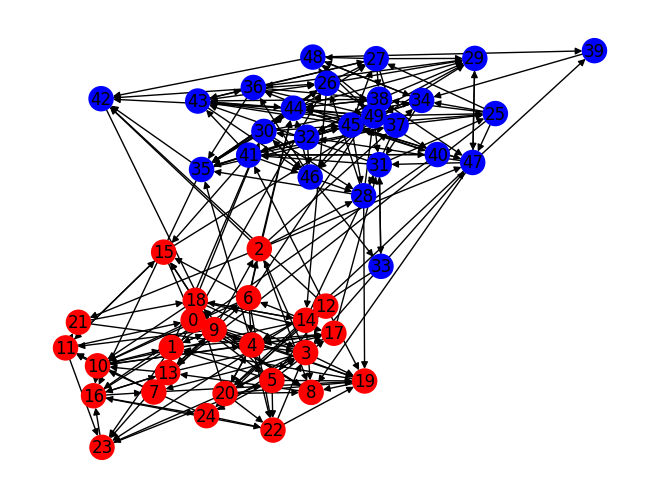

In [239]:
graph = nx.planted_partition_graph(2, 25, 0.15, 0.02, directed=True)

for i in range(25 * 2):
    if graph.nodes[i]['block'] == 0:
        graph.nodes[i]['opinion'] = random_in_range((-1, -0.0001)) # Community 0, 2
    else:
        graph.nodes[i]['opinion'] = random_in_range((0.0001, 1))  # Community 1, 3

for i in range(graph.number_of_edges()):
    opinion_a = graph.nodes[list(graph.edges)[i][0]]['opinion']
    opinion_b = graph.nodes[list(graph.edges)[i][1]]['opinion']
    if (opinion_a < 0 and opinion_b > 0) or (opinion_a > 0 and opinion_b < 0):
        graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((toxicity_threshold, 1.0)))
    else:
        graph.edges[list(graph.edges)[i]]['weight'] = get_weight_from_toxicity(random_in_range((0.0, toxicity_threshold)))

nx.draw(graph, with_labels=True, node_color=['red' if graph.nodes[i]['opinion'] < 0 else 'blue' for i in graph.nodes])

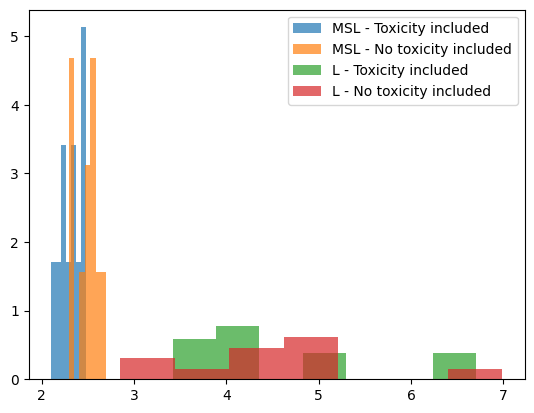

In [236]:
for k in keys:
    plt.hist(temp_results[k].values(), bins=7, density=True, alpha=0.7)
plt.legend([k for k in temp_results.keys()])